# MLP_model
#### Modèle MLP multi-cibles pour la prediction des conso_énergétiques
Après l'établissement d'un modèle de référence basé sur LightGBM, un réseau de neurones de type Multi-Layer Perceptron (MLP) est entraîné sur le même découpage stratifié des données.
L'objectif est de comparer les performances d'un modèle de Deep Learning avec un modèle basé sur les arbres de décision, en utilisant les mêmes jeux d'entraînement, validation et test.


In [ ]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split


import matplotlib.pyplot as plt


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path

ROOT = Path().resolve().parent.parent
DATA = ROOT / "data" / "processed"

X = pd.read_parquet(DATA / "X.parquet")
Y = pd.read_parquet(DATA / "y.parquet")

idx_train = np.load(DATA / "idx_train.npy")
idx_test  = np.load(DATA / "idx_test.npy")

X_train = X.iloc[idx_train].reset_index(drop=True)
X_test  = X.iloc[idx_test].reset_index(drop=True)

Y_train = Y.iloc[idx_train].reset_index(drop=True)
Y_test  = Y.iloc[idx_test].reset_index(drop=True)
X_total = len(X_train) + len(X_test)
Y_total = len(Y_train) + len(Y_test)


labels_df = pd.read_parquet(DATA / "cluster_labels.parquet")

print(f"Train : {X_train.shape} ({len(X_train)/X_total:.1%})")
print(f"Test  : {X_test.shape} ({len(X_test)/X_total:.1%})")

print(f"Train : {Y_train.shape} ({len(Y_train)/Y_total:.1%})")
print(f"Test  : {Y_test.shape} ({len(Y_test)/Y_total:.1%})")


Train : (439976, 110) (80.0%)
Test  : (109995, 110) (20.0%)
Train : (439976, 5) (80.0%)
Test  : (109995, 5) (20.0%)


## Creation de la validation-set

In [45]:
'''
X_train_final, X_val, Y_train_final, Y_val = train_test_split(
    X_train,
    Y_train,
    test_size=0.2,
    random_state=42
)
X_total = len(X_train_final) + len(X_val) + len(X_test)
Y_total = len(Y_train_final) + len(Y_val) + len(Y_test)

print(f"Train : {X_train_final.shape} ({len(X_train_final)/X_total:.1%})")
print(f"Val   : {X_val.shape} ({len(X_val)/X_total:.1%})")
print(f"Test  : {X_test.shape} ({len(X_test)/X_total:.1%})")

print(f"Train : {Y_train_final.shape} ({len(Y_train_final)/Y_total:.1%})")
print(f"Val   : {Y_val.shape} ({len(Y_val)/Y_total:.1%})")
print(f"Test  : {Y_test.shape} ({len(Y_test)/Y_total:.1%})")

'''

# Split train/val STRATIFIÉ — cohérent avec lightgbm_stratified.ipynb


# Récupérer les strates pour les indices train uniquement
stratum_train = labels_df.iloc[idx_train]["stratum_final"].reset_index(drop=True)


# Split stratifié train / val
X_train_final, X_val, Y_train_final, Y_val = train_test_split(
    X_train,
    Y_train,
    test_size=0.2,
    random_state=42,
    stratify=stratum_train        # ← correction : stratification explicite
)

X_total = len(X_train_final) + len(X_val) + len(X_test)

print(f"\nSplit final (stratifié, cohérent avec LightGBM)")
print(f"  Train : {X_train_final.shape}  ({len(X_train_final)/X_total:.1%})")
print(f"  Val   : {X_val.shape}  ({len(X_val)/X_total:.1%})")
print(f"  Test  : {X_test.shape}  ({len(X_test)/X_total:.1%})")





Split final (stratifié, cohérent avec LightGBM)
  Train : (351980, 110)  (64.0%)
  Val   : (87996, 110)  (16.0%)
  Test  : (109995, 110)  (20.0%)


## La normalisation

In [ ]:
scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train_final)
X_val_scaled   = scaler_X.transform(X_val)
X_test_scaled  = scaler_X.transform(X_test)

scaler_Y = StandardScaler()

Y_train_scaled = scaler_Y.fit_transform(Y_train_final)
Y_val_scaled   = scaler_Y.transform(Y_val)
Y_test_scaled  = scaler_Y.transform(Y_test)

X_total = len(X_train_scaled) + len(X_val_scaled) + len(X_test_scaled)
Y_total = len(Y_train_scaled) + len(Y_val_scaled) + len(Y_test_scaled)

print(f"Train : {X_train_final.shape} ({len(X_train_final)/X_total:.1%})")
print(f"Val   : {X_val.shape} ({len(X_val)/X_total:.1%})")
print(f"Test  : {X_test.shape} ({len(X_test)/X_total:.1%})")

print(f"Train : {Y_train_final.shape} ({len(Y_train_final)/Y_total:.1%})")
print(f"Val   : {Y_val.shape} ({len(Y_val)/Y_total:.1%})")
print(f"Test  : {Y_test.shape} ({len(Y_test)/Y_total:.1%})")




Train : (351980, 110) (64.0%)
Val   : (87996, 110) (16.0%)
Test  : (109995, 110) (20.0%)
Train : (351980, 5) (64.0%)
Val   : (87996, 5) (16.0%)
Test  : (109995, 5) (20.0%)


## Définition De dimensions

In [47]:
n_features = X_train_scaled.shape[1]
n_targets  = Y_train_scaled.shape[1]

print("Features :", n_features)
print("Targets  :", n_targets)


Features : 110
Targets  : 5


## Construction de notere modèle MLP et Compilation 

In [48]:
model = keras.Sequential([
    layers.Dense(512, activation="relu", input_shape=(n_features,)),
    layers.Dropout(0.2),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(128, activation="relu"),

    layers.Dense(n_targets)  # sortie multi-target
])

model.summary()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)


C:\Users\yzouarhi\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 512)            │        56,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221,701 (866.02 KB)

 Trainable params: 221,701 (866.02 KB)

 Non-trainable params: 0 (0.00 B)

## 

## Entrainement

In [49]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    Y_train_scaled,
    validation_data=(X_val_scaled, Y_val_scaled),
    epochs=200,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/200
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.3545 - mae: 0.2738 - val_loss: 0.3073 - val_mae: 0.2288
Epoch 2/200
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2984 - mae: 0.2326 - val_loss: 0.2910 - val_mae: 0.2217
Epoch 3/200
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2820 - mae: 0.2215 - val_loss: 0.2925 - val_mae: 0.2296
Epoch 4/200
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2731 - mae: 0.2168 - val_loss: 0.2756 - val_mae: 0.2095
Epoch 5/200
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2638 - mae: 0.2127 - val_loss: 0.2772 - val_mae: 0.2102
Epoch 6/200
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2568 - mae: 0.2100 - val_loss: 0.2828 - val_mae: 0.2184
Epoch 7/200
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2498 - mae: 0.2074 - val_loss: 0.2792 - val_mae: 0.2070
Epoch 8/200
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2428 - mae: 0.2055 - val_loss: 0.2801 - val_mae: 0.2111
Epoch 9/200
1375/1375 ━━━━━━━━━━

## visualisation des courbes d'apprentissage

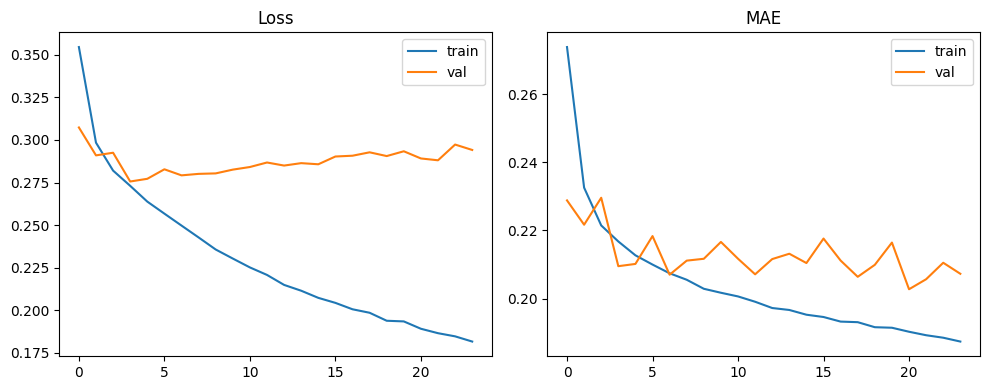

In [50]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["mae"], label="train")
plt.plot(history.history["val_mae"], label="val")
plt.title("MAE")
plt.legend()

plt.tight_layout()
plt.show()


In [66]:

Y_train_pred = model.predict(X_train_scaled)
Y_val_pred   = model.predict(X_val_scaled)
Y_test_pred  = model.predict(X_test_scaled)

Y_train_pred = scaler_Y.inverse_transform(Y_train_pred)
Y_val_pred   = scaler_Y.inverse_transform(Y_val_pred)
Y_test_pred  = scaler_Y.inverse_transform(Y_test_pred)

Y_train_true = Y_train_final.values
Y_val_true   = Y_val.values
Y_test_true  = Y_test.values

results = {}

for i, target in enumerate(Y.columns):

    train_rmse = np.sqrt(mean_squared_error(Y_train_true[:, i], Y_train_pred[:, i]))
    train_mae  = mean_absolute_error(Y_train_true[:, i], Y_train_pred[:, i])
    train_r2   = r2_score(Y_train_true[:, i], Y_train_pred[:, i])

    val_rmse = np.sqrt(mean_squared_error(Y_val_true[:, i], Y_val_pred[:, i]))
    val_mae  = mean_absolute_error(Y_val_true[:, i], Y_val_pred[:, i])
    val_r2   = r2_score(Y_val_true[:, i], Y_val_pred[:, i])

    test_rmse = np.sqrt(mean_squared_error(Y_test_true[:, i], Y_test_pred[:, i]))
    test_mae  = mean_absolute_error(Y_test_true[:, i], Y_test_pred[:, i])
    test_r2   = r2_score(Y_test_true[:, i], Y_test_pred[:, i])

    results[target] = {
        "Train_RMSE": train_rmse,
        "Train_MAE": train_mae,
        "Train_R2": train_r2,
        "Val_RMSE": val_rmse,
        "Val_MAE": val_mae,
        "Val_R2": val_r2,
        "Test_RMSE": test_rmse,
        "Test_MAE": test_mae,
        "Test_R2": test_r2,
    }

df_results = pd.DataFrame(results).T
df_results["Overfit_Gap"] = df_results["Train_R2"] - df_results["Test_R2"]
df_results = df_results.sort_values("Test_R2", ascending=False)

display(df_results.round(4))


11000/11000 ━━━━━━━━━━━━━━━━━━━━ 5s 478us/step
2750/2750 ━━━━━━━━━━━━━━━━━━━━ 1s 468us/step
3438/3438 ━━━━━━━━━━━━━━━━━━━━ 2s 460us/step


,Train_RMSE,Train_MAE,Train_R2,Val_RMSE,Val_MAE,Val_R2,Test_RMSE,Test_MAE,Test_R2,Overfit_Gap
out.emissions.total.lrmer_mid_case_25..co2e_kg,1536.5554,970.2053,0.8830,1606.5922,990.9788,0.8720,1594.8150,988.5945,0.8721,0.0109
out.natural_gas.total.energy_consumption..kwh,6310.4802,3284.8984,0.8505,6383.7039,3313.6106,0.8459,6430.1301,3335.9517,0.8429,0.0076
out.electricity.total.energy_consumption..kwh,3772.1626,2349.1498,0.8090,3852.8860,2379.8441,0.8002,3859.9092,2380.7892,0.7971,0.0119
out.fuel_oil.total.energy_consumption..kwh,3953.6326,1080.7786,0.6873,4349.0872,1146.8153,0.6311,4264.2458,1139.4667,0.6264,0.0609
out.propane.total.energy_consumption..kwh,4092.8884,1084.1413,0.5590,4442.8146,1146.8922,0.4891,4523.4501,1156.0835,0.4668,0.0923



=== out.electricity.total.energy_consumption..kwh ===
[ 8561.77824482  5156.2924091   1420.80854833 15989.66451904
 30495.80328073]
[ 9442.199   7010.6963  4449.014  17906.846  26867.457 ]


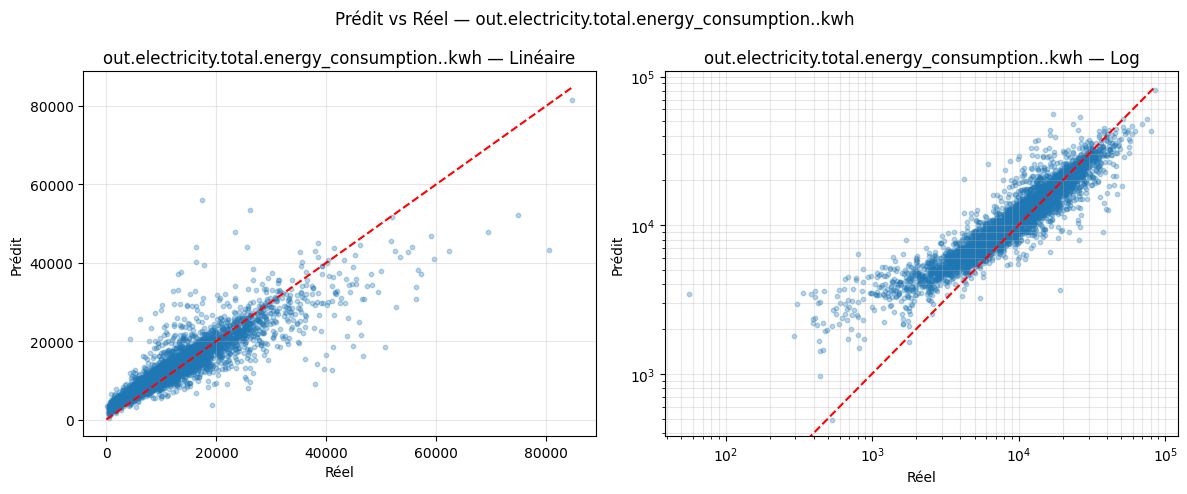


=== out.natural_gas.total.energy_consumption..kwh ===
[0. 0. 0. 0. 0.]
[9381.246    795.36914 1739.2324  1808.3418  1326.5273 ]


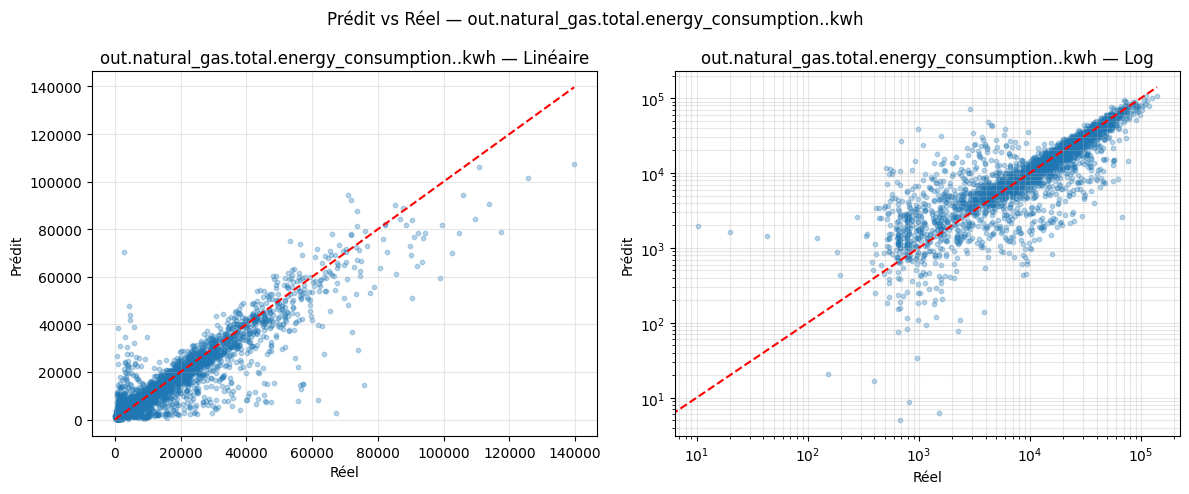


=== out.fuel_oil.total.energy_consumption..kwh ===
[26808.96921762     0.             0.             0.
     0.        ]
[1.7187537e+04 1.2021851e+01 1.5526367e+01 8.5591718e+02 2.6112671e+02]


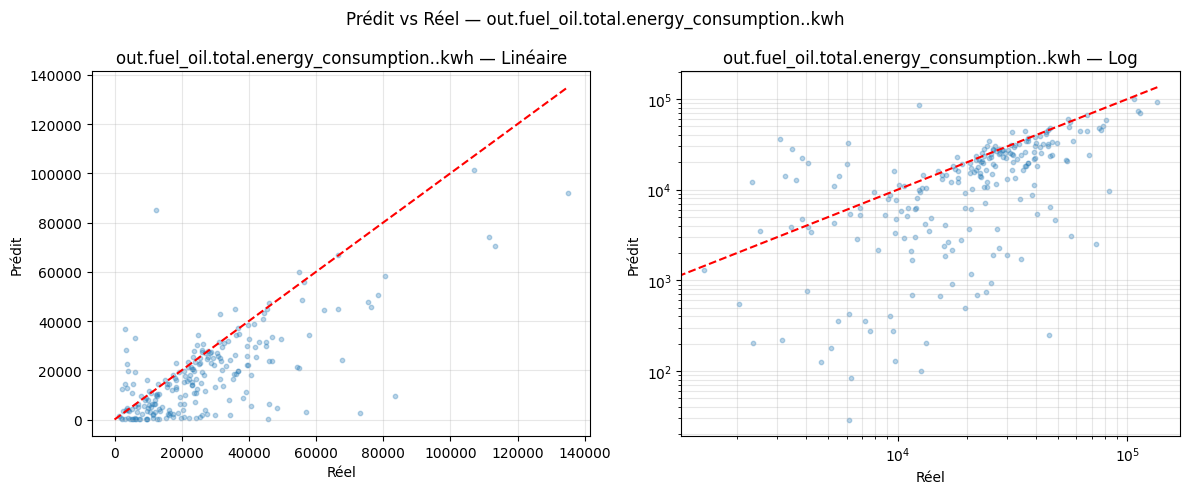


=== out.propane.total.energy_consumption..kwh ===
[0. 0. 0. 0. 0.]
[1765.3043    230.3974    -84.905396  620.5459   -155.3689  ]


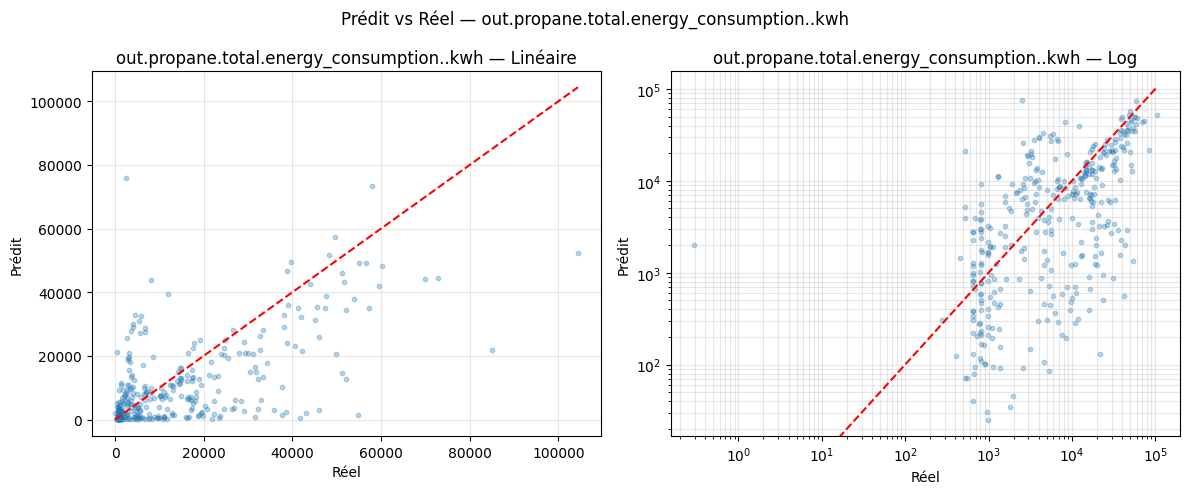


=== out.emissions.total.lrmer_mid_case_25..co2e_kg ===
[10404.57889376  1296.81604991    94.20659933  4271.18451325
  7262.42207683]
[9788.254   1916.356    909.49756 5160.3735  5376.002  ]


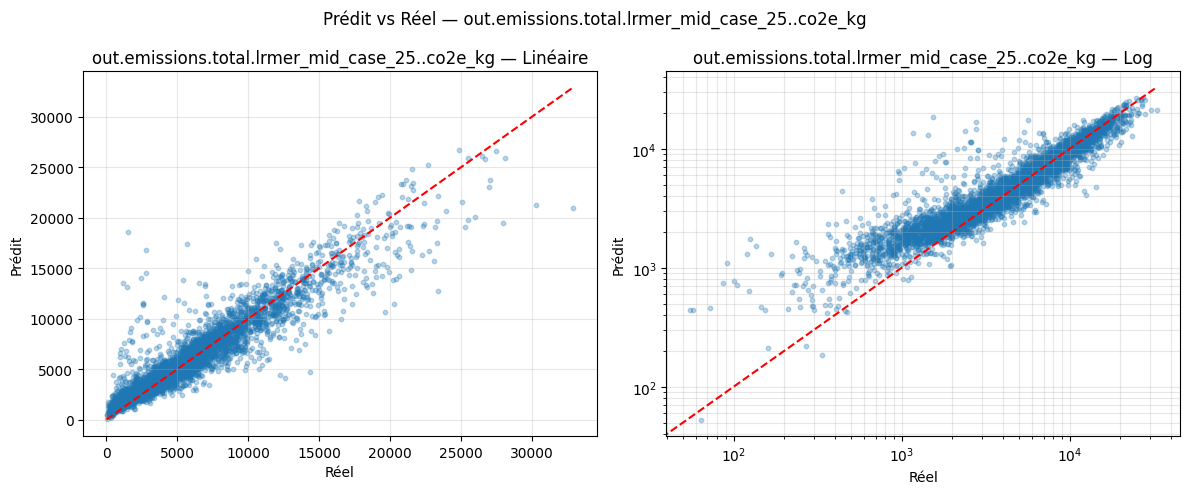

In [72]:
rng = np.random.default_rng(42)

Y_true = Y_test_true
Y_pred = Y_test_pred
for i, col in enumerate(Y.columns):

    y_true = Y_true[:, i]
    y_pred = Y_pred[:, i]
    print(f"\n=== {col} ===")
    print(y_true[:5])
    print(y_pred[:5])

    # échantillon
    n = min(5000, len(y_true))
    idx = rng.choice(len(y_true), n, replace=False)

    y_true_s = y_true[idx]
    y_pred_s = y_pred[idx]

    # éviter log(0)
    mask = (y_true_s > 0) & (y_pred_s > 0)
    y_true_s = y_true_s[mask]
    y_pred_s = y_pred_s[mask]

    lim = max(y_true_s.max(), y_pred_s.max())

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

  # linéraire
    axes[0].scatter(y_true_s, y_pred_s, alpha=0.3, s=10)
    axes[0].plot([0, lim], [0, lim], "r--")
    axes[0].set_title(f"{col} — Linéaire")
    axes[0].set_xlabel("Réel")
    axes[0].set_ylabel("Prédit")
    axes[0].grid(alpha=0.3)

  # log
    axes[1].scatter(y_true_s, y_pred_s, alpha=0.3, s=10)
    axes[1].plot([0, lim], [0, lim], "r--")
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    axes[1].set_title(f"{col} — Log")
    axes[1].set_xlabel("Réel")
    axes[1].set_ylabel("Prédit")
    axes[1].grid(alpha=0.3, which="both")

    plt.suptitle(f"Prédit vs Réel — {col}")
    plt.tight_layout()
    plt.show()
